<a href="https://colab.research.google.com/github/kuruvasandhya/DeepLearning/blob/main/SandhyaDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset ready!
Found 6404 images belonging to 2 classes.
Found 1601 images belonging to 2 classes.

Training ALEXNET...
Epoch 1/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.4989 - loss: 0.6962 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 2/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.4939 - loss: 0.6937 - val_accuracy: 0.5003 - val_loss: 0.6933
Epoch 3/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5014 - loss: 0.6937 - val_accuracy: 0.5084 - val_loss: 0.6927
Epoch 4/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4847 - loss: 0.6973 - val_accuracy: 0.4997 - val_loss: 0.6928
Epoch 5/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5078 - loss: 0.6974 - val_accuracy: 0.5034 - val_loss: 0.6928
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step

Training VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.8307 - loss: 0.3699 - val_accuracy: 0.8751 - val_loss: 0

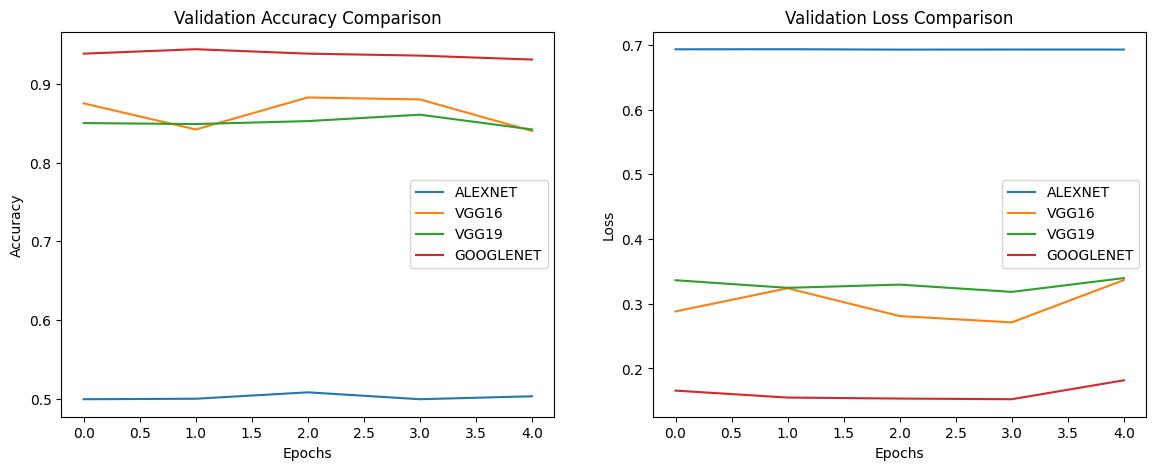

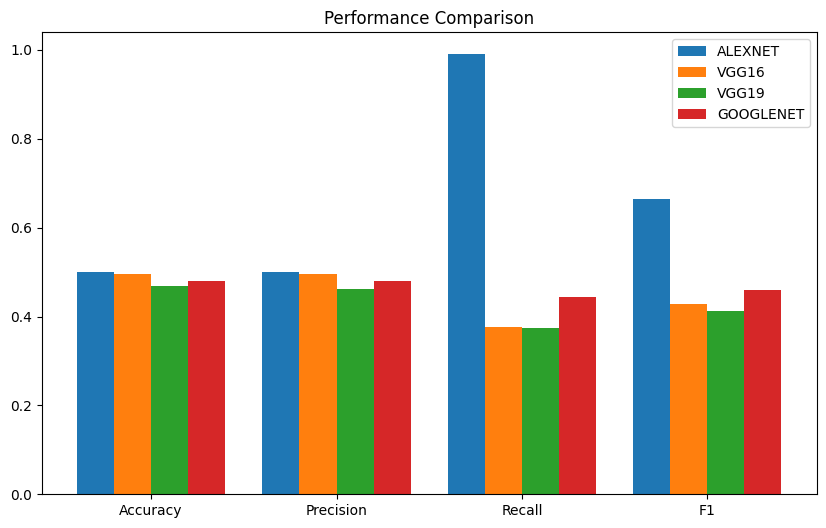


===== ALEXNET REPORT =====
              precision    recall  f1-score   support

         Cat       0.47      0.01      0.02       800
         Dog       0.50      0.99      0.66       801

    accuracy                           0.50      1601
   macro avg       0.48      0.50      0.34      1601
weighted avg       0.48      0.50      0.34      1601


===== VGG16 REPORT =====
              precision    recall  f1-score   support

         Cat       0.50      0.62      0.55       800
         Dog       0.50      0.38      0.43       801

    accuracy                           0.50      1601
   macro avg       0.50      0.50      0.49      1601
weighted avg       0.50      0.50      0.49      1601


===== VGG19 REPORT =====
              precision    recall  f1-score   support

         Cat       0.47      0.57      0.52       800
         Dog       0.46      0.37      0.41       801

    accuracy                           0.47      1601
   macro avg       0.47      0.47      0.46     

In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import os
import zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

# ==============================
# 2. DOWNLOAD DATASET (KAGGLE API)
# ==============================
print("Downloading dataset...")
os.system("kaggle datasets download -d tongpython/cat-and-dog")

if not os.path.exists("dataset"):
    with zipfile.ZipFile("cat-and-dog.zip", 'r') as zip_ref:
        zip_ref.extractall("dataset")

print("Dataset ready!")

# ==============================
# 3. LOAD DATA (LOW MEMORY FIX)
# ==============================
def load_data():
    train_dir = "dataset/training_set/training_set"

    datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2
    )

    train_data = datagen.flow_from_directory(
        train_dir,
        target_size=(128,128),   # ✅ reduced size
        batch_size=8,            # ✅ reduced batch
        class_mode='binary',
        subset='training'
    )

    val_data = datagen.flow_from_directory(
        train_dir,
        target_size=(128,128),
        batch_size=8,
        class_mode='binary',
        subset='validation'
    )

    return train_data, val_data

train_data, val_data = load_data()

# ==============================
# 4. MODEL ARCHITECTURES (FIXED)
# ==============================
def get_architecture(name):

    if name == 'vgg16':
        base = applications.VGG16(input_shape=(128,128,3), include_top=False, weights='imagenet')

    elif name == 'vgg19':
        base = applications.VGG19(input_shape=(128,128,3), include_top=False, weights='imagenet')

    elif name == 'googlenet':
        base = applications.InceptionV3(input_shape=(128,128,3), include_top=False, weights='imagenet')

    elif name == 'alexnet':
        model = models.Sequential([
            layers.Input(shape=(128,128,3)),
            layers.Conv2D(96, 11, strides=4, activation='relu'),
            layers.MaxPooling2D(3, strides=2),
            layers.Conv2D(256, 5, padding='same', activation='relu'),
            layers.MaxPooling2D(3, strides=2),
            layers.Flatten(),
            layers.Dense(512, activation='relu'),   # reduced
            layers.Dropout(0.5),
            layers.Dense(1, activation='sigmoid')
        ])

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return model

    # Freeze pretrained layers
    for layer in base.layers:
        layer.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base.input, outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

# ==============================
# 5. TRAINING & EVALUATION
# ==============================
architectures = ['alexnet', 'vgg16', 'vgg19', 'googlenet']
results = {}

for arch in architectures:
    print(f"\nTraining {arch.upper()}...")

    tf.keras.backend.clear_session()  # ✅ prevent memory buildup

    model = get_architecture(arch)

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=5,
        verbose=1
    )

    # Predictions
    y_pred_prob = model.predict(val_data)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    y_true = val_data.classes

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    report = classification_report(
        y_true, y_pred,
        target_names=['Cat', 'Dog'],
        zero_division=0
    )

    results[arch] = {
        'history': history.history,
        'metrics': [acc, prec, rec, f1],
        'report': report
    }

# ==============================
# 6. VISUALIZATION
# ==============================
def plot_results(results):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

    for arch, data in results.items():
        ax1.plot(data['history']['val_accuracy'], label=arch.upper())
        ax2.plot(data['history']['val_loss'], label=arch.upper())

    ax1.set_title("Validation Accuracy Comparison")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.set_title("Validation Loss Comparison")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.show()

def plot_metric_bars(results):
    labels = ['Accuracy', 'Precision', 'Recall', 'F1']
    x = np.arange(len(labels))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10,6))

    for i, (arch, data) in enumerate(results.items()):
        ax.bar(x + (i-1.5)*width, data['metrics'], width, label=arch.upper())

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title("Performance Comparison")
    ax.legend()

    plt.show()

# Run plots
plot_results(results)
plot_metric_bars(results)

# ==============================
# 7. CLASSIFICATION REPORTS
# ==============================
for arch, data in results.items():
    print(f"\n===== {arch.upper()} REPORT =====")
    print(data['report'])